# Census OCR — IDE / Colab Extension

**Ready to run.** Connect a Colab GPU runtime, then **Run All**.

This notebook auto-downloads project files (images, ground truth, prompts) from Hugging Face.
No manual upload or zip copying needed.


## 1. Setup

In [8]:
!pip install -q "transformers>=4.49" accelerate bitsandbytes qwen-vl-utils openpyxl pandas fuzzywuzzy python-levenshtein matplotlib python-dotenv huggingface_hub einops


## 2. Bootstrap project + HF auth


In [21]:
# === CONFIG: paste HF token + bootstrap method ===
import os, shutil, subprocess, zipfile, sys
from pathlib import Path

HF_TOKEN = os.environ.get("HF_TOKEN") or ""  # set in .env; run: python colab/prepare_ide_colab.py
PROJECT_DIR_OVERRIDE = None
GIT_REPO_URL = ""  # not needed — zip URL is pre-set
REMOTE_ZIP_URL = "https://huggingface.co/datasets/damkamanii/poc-textual-colab/resolve/main/poc_textual_colab.zip"
LOCAL_ZIP_ON_COLAB = Path("/content/poc_textual_colab.zip")
COLAB_PROJECT_DIR = Path("/content/poc_textual")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN

def _is_project_root(p):
    p = Path(p)
    return (
        (p / "src" / "compare.py").is_file()
        and (p / "data" / "ground_truth").is_dir()
        and (p / "prompts").is_dir()
    )

def _find_root():
    if PROJECT_DIR_OVERRIDE and _is_project_root(Path(PROJECT_DIR_OVERRIDE)):
        return Path(PROJECT_DIR_OVERRIDE).resolve()
    bases = [Path.cwd(), Path("/content"), COLAB_PROJECT_DIR, Path("/content/poc_textual")]
    if Path("/content").exists():
        bases += [p.parent for p in Path("/content").rglob("compare.py") if p.parent.name == "src"]
        bases += [p.parent.parent for p in Path("/content").rglob("compare.py") if p.parent.name == "src"]
    for p in dict.fromkeys(Path(b).resolve() for b in bases if Path(b).exists()):
        if _is_project_root(p):
            return p
    return None

def bootstrap_project():
    found = _find_root()
    if found:
        print("Project found:", found); return found
    if GIT_REPO_URL:
        if COLAB_PROJECT_DIR.exists(): shutil.rmtree(COLAB_PROJECT_DIR)
        subprocess.check_call(["git","clone","--depth","1",GIT_REPO_URL,str(COLAB_PROJECT_DIR)])
    elif REMOTE_ZIP_URL:
        import shutil
        if COLAB_PROJECT_DIR.exists(): shutil.rmtree(COLAB_PROJECT_DIR)
        zp = Path("/content/_poc.zip"); subprocess.check_call(["wget","-q","-O",str(zp),REMOTE_ZIP_URL])
        zipfile.ZipFile(zp).extractall("/content"); zp.unlink(missing_ok=True)
        print("Extracted zip to /content/")
    elif LOCAL_ZIP_ON_COLAB.is_file():
        zipfile.ZipFile(LOCAL_ZIP_ON_COLAB).extractall("/content")
    else:
        raise FileNotFoundError("Colab VM has no repo files. Set GIT_REPO_URL, REMOTE_ZIP_URL, or copy poc_textual_colab.zip to /content/")
    # zip extracts to /content/poc_textual/...
    search = [COLAB_PROJECT_DIR, Path("/content/poc_textual")]
    search += [p.parent.parent for p in Path("/content").rglob("compare.py") if p.name == "compare.py" and p.parent.name == "src"]
    for c in dict.fromkeys(search):
        if _is_project_root(c):
            print("Bootstrapped:", c)
            return c.resolve()
    # debug: show what landed on disk
    if Path("/content").exists():
        print("DEBUG /content:", [x.name for x in Path("/content").iterdir()])
        poc = Path("/content/poc_textual")
        if poc.exists():
            print("DEBUG poc_textual:", [x.name for x in poc.iterdir()])
    raise FileNotFoundError("Bootstrap done but project root not found")

PROJECT_DIR = bootstrap_project()

def setup_paths(d):
    return {"gt": d/"data/ground_truth/Bastrop County 1950 Clean.xlsx", "images": d/"data/raw_images/1950_11-1",
            "outputs": d/"data/outputs/1950_11-1", "results": d/"results/colab_ide", "prompts": d/"prompts", "src": d/"src"}

PATHS = setup_paths(PROJECT_DIR)
try:
    from dotenv import load_dotenv; load_dotenv(PROJECT_DIR/".env")
except ImportError: pass
token = os.environ.get("HF_TOKEN") or HF_TOKEN
if not token: raise RuntimeError("Set HF_TOKEN in this cell")
from huggingface_hub import login; login(token=token, add_to_git_credential=False); os.environ["HF_TOKEN"]=token
print("HF authenticated")
s = str(PATHS["src"]); sys.path.insert(0, s) if s not in sys.path else None
GT_PATH, IMAGE_DIR = PATHS["gt"], PATHS["images"]
OUTPUT_DIR, RESULTS_DIR, PROMPTS_DIR = PATHS["outputs"], PATHS["results"], PATHS["prompts"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Project:", PROJECT_DIR); print("GT:", GT_PATH.exists()); print("Images:", len(list(IMAGE_DIR.glob("*.jpg"))))
assert GT_PATH.exists() and IMAGE_DIR.exists()



Project found: /content/poc_textual


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF authenticated
Project: /content/poc_textual
GT: True
Images: 13


In [22]:
import torch
VRAM_GB = torch.cuda.get_device_properties(0).total_memory/1e9 if torch.cuda.is_available() else 0
print(f'VRAM: {VRAM_GB:.1f} GB')
MODEL_ID="Qwen/Qwen2.5-VL-32B-Instruct"
FALLBACK="Qwen/Qwen2.5-VL-7B-Instruct"
LOAD_IN_4BIT=True
MAX_NEW_TOKENS=4096
# Source scans are ~1740x1456 (~2.5MP) legal-size forms with 30 dense rows of
# cursive handwriting. The old cap (1280*28*28 ~= 1.0MP) silently downscaled
# every image to ~63% of native size before it reached the model -- squeezing
# each row into ~30px tall, small enough that names/ages became illegible and
# the model hallucinated a plausible-looking but entirely fabricated
# household instead of the real one (confirmed by diffing model output
# against the actual scan: extracted 'Judd' family vs. the real 'Whitehead'
# family clearly visible on the page). Raise the cap to keep native
# resolution with headroom.
MAX_PIXELS=6144*28*28
SELECTED_MODEL=MODEL_ID if VRAM_GB>=20 else FALLBACK
print('Model:', SELECTED_MODEL, '| MAX_PIXELS:', MAX_PIXELS, f'(~{MAX_PIXELS/1e6:.1f} MP)')


VRAM: 85.1 GB
Model: Qwen/Qwen2.5-VL-32B-Instruct | MAX_PIXELS: 4816896 (~4.8 MP)


In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True) if LOAD_IN_4BIT else None
print(f"Loading {SELECTED_MODEL}...")
processor = AutoProcessor.from_pretrained(SELECTED_MODEL, trust_remote_code=True)
# attn_implementation="sdpa" -- now that MAX_PIXELS is ~5x larger (step 6 needs
# it for legibility, see cell above), vision-token count is ~5x larger too and
# attention cost scales with sequence length. SDPA uses PyTorch's fused
# attention kernel instead of the slower default "eager" path -- free speed,
# no extra pip install, no accuracy tradeoff. If flash-attn is installed in
# this Colab runtime, "flash_attention_2" is faster still.
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    SELECTED_MODEL, quantization_config=bnb, device_map="auto",
    torch_dtype=torch.bfloat16, trust_remote_code=True, attn_implementation="sdpa")
model.eval()
print("Model ready.")


## 3. Configure the run

Set the census year and the exact ground-truth sheet name to compare against.

**Verified-clean 1950 sheets (no known typos):** `Bastrop 11-3`, `Bastrop 11-2A`,
`Smithville 11-10`, `Elgin 11-20`, `Elgin 11-21`.
Avoid `Bastrop all Manipulated`, `Bastrop 11-2B`, `Bastrop 11-1`,
`Smithville 11-7`, `Smithville 11-8`, `Smithville 11-9` for now — these contain
stray/typo values in their Race column that are ground-truth data-entry
mistakes, not extraction errors.

In [24]:
CENSUS_YEAR=1950
GROUND_TRUTH_SHEET="Bastrop 11-1"
ENUMERATION_DISTRICT="11-1"
PHYSICAL_PAGE=1
if "IMAGE_FILENAME" not in dir(): IMAGE_FILENAME="sheet_01.jpg"
if "RUN_BATCH" not in dir(): RUN_BATCH=False
BATCH_PAGES=list(range(1,12))
print("page",PHYSICAL_PAGE,"image",IMAGE_FILENAME,"batch",RUN_BATCH)


page 1 image sheet_01.jpg batch False


## 4. Schema & normalization utilities

Verified directly against the ground truth files -- see `CLAUDE.md` for the full investigation. **Do not treat these as textbook census categories** — several are a research-team-specific controlled vocabulary that a vision model reading the raw image cannot produce directly (e.g. "Negro (Black)", "Mexican (Latino)", and especially the 1950 "W0"/"WO" sub-code, which is not visible anywhere on the physical form).

In [25]:
BIRTHPLACE_COLUMN = {
    1850: "Birth Place", 1860: "Birth Place", 1950: "Birth Place",
    1870: "Birthplace", 1880: "Birthplace", 1900: "Birthplace",
    1910: "Birthplace", 1920: "Birthplace", 1930: "Birthplace", 1940: "Birthplace",
}

GENDER_COLUMN = {1920: "Sex"}  # every other decade uses "Gender"

HAS_LINE_NUMBER = {
    1850: True, 1860: False,  # 1860 confirmed to have NO Line Number column anywhere
    1870: True, 1880: True, 1900: True, 1910: True,
    1920: True, 1930: True, 1940: True, 1950: True,
}

# Race values ACTUALLY OBSERVED in the ground truth per decade (verified by
# scanning every sheet in every workbook -- not textbook categories)
VALID_RACE = {
    1850: ["White", "Black", "Mulatto"],
    1860: ["White", "Black", "Mulatto", "Indian (Native American)"],
    1870: ["White", "Black", "Mulatto"],
    1880: ["White", "Black", "Mulatto", "Filipino"],
    1900: ["White", "Black", "Mulatto", "Chinese", "Mexican (Latino)"],
    1910: ["White", "Black", "Mulatto", "Octoroon", "Mexican (Latino)", "Other"],
    1920: ["White", "Black", "Mulatto", "Mexican (Latino)"],
    1930: ["White", "Black", "Negro (Black)", "Mulatto", "Mexican (Latino)"],
    1940: ["White", "Negro (Black)"],
    1950: ["White", "Negro (Black)", "Chinese", "W0", "WO"],
}

# Raw form code (what a vision model reads off the image) -> ground truth string
RACE_NORMALIZE_MAP = {
    1950: {"W": "White", "Neg": "Negro (Black)", "Ch": "Chinese"},
    1940: {"W": "White", "Ne": "Negro (Black)", "Neg": "Negro (Black)"},
    1930: {"W": "White", "B": "Black", "Mu": "Mulatto", "Mex": "Mexican (Latino)", "Neg": "Negro (Black)"},
    1920: {"W": "White", "B": "Black", "Mu": "Mulatto", "Mex": "Mexican (Latino)"},
    1910: {"W": "White", "B": "Black", "Mu": "Mulatto", "Ot": "Octoroon", "Mex": "Mexican (Latino)"},
    1900: {"W": "White", "B": "Black", "Mu": "Mulatto", "Ch": "Chinese", "Mex": "Mexican (Latino)"},
    1880: {"W": "White", "B": "Black", "Mu": "Mulatto", "Fil": "Filipino"},
    1870: {"W": "White", "B": "Black", "Mu": "Mulatto"},
    1860: {"W": "White", "B": "Black", "Mu": "Mulatto", "In": "Indian (Native American)"},
    1850: {"W": "White", "B": "Black", "Mu": "Mulatto"},
    # "W0"/"WO" (1950) intentionally excluded -- not derivable from the image, see CLAUDE.md
}

VALID_GENDER = ["Male", "Female"]

VALID_MARITAL_STATUS = {
    1880: ["Married", "Single", "Widowed", "Widower", "Divorced", "Na"],
    1900: ["Married", "Single", "Widowed", "Divorced"],
    1910: ["Married", "Single", "Widowed", "Divorced"],
    1920: ["Married", "Single", "Widowed", "Divorced"],
    1930: ["Married", "Single", "Widowed", "Divorced"],
    1940: ["Married", "Single", "Widowed", "Divorced"],
    1950: ["Married", "Never Married (Single)", "Widowed", "Divorced", "Separated"],
}


def normalize_race(raw, year):
    if not raw:
        return raw
    raw = raw.strip()
    decade_map = RACE_NORMALIZE_MAP.get(year, {})
    if raw in decade_map:
        return decade_map[raw]
    for v in VALID_RACE.get(year, []):
        if raw.lower() == v.lower():
            return v
    return raw


def normalize_gender(raw):
    if not raw:
        return raw
    raw = raw.strip().upper()
    if raw in ["M", "MALE"]:
        return "Male"
    if raw in ["F", "FEMALE"]:
        return "Female"
    return raw


def propagate_dittos(records, surname_field="Surname", birthplace_field="Birthplace"):
    prev_surname, prev_birthplace = None, None
    ditto_markers = [None, "", "\u2014\u2014", '"', "''", "ditto", "do", "Do", "DO"]
    for rec in records:
        surname = rec.get(surname_field)
        if surname in ditto_markers:
            if prev_surname:
                rec[surname_field] = prev_surname
        else:
            prev_surname = surname
        birthplace = rec.get(birthplace_field)
        if birthplace in ditto_markers:
            if prev_birthplace:
                rec[birthplace_field] = prev_birthplace
        else:
            prev_birthplace = birthplace
    return records

print("Utilities loaded.")

# Maps the raw abbreviation a vision model reads off the form (Mar, Wd, D, S...)
# to the ground-truth string for that decade. CONFIRMED NECESSARY: fuzzy string
# matching fails badly on these (e.g. "mar" vs "married" scores only 60/100,
# "d" vs "divorced" scores 22/100, both well below any reasonable threshold) --
# without this normalization, correct extractions get marked as wrong.
MARITAL_STATUS_NORMALIZE_MAP = {
    1950: {"Mar": "Married", "Wd": "Widowed", "D": "Divorced", "Sep": "Separated",
           "S": "Never Married (Single)"},
    "default": {"Mar": "Married", "M": "Married", "Wd": "Widowed", "W": "Widowed",
                "D": "Divorced", "S": "Single", "Sep": "Separated"},
}


def normalize_marital_status(raw, year):
    if not raw:
        return raw
    raw = raw.strip()
    decade_map = MARITAL_STATUS_NORMALIZE_MAP.get(year, MARITAL_STATUS_NORMALIZE_MAP["default"])
    if raw in decade_map:
        return decade_map[raw]
    for v in VALID_MARITAL_STATUS.get(year, []):
        if raw.lower() == v.lower():
            return v
    return raw


Utilities loaded.


## 5. Extraction prompt for this decade

Uses the verified schema and instructs the model to transcribe raw marks rather than expand or normalize them (normalization happens separately, below).

In [26]:
SYSTEM_PROMPT = (PROMPTS_DIR / 'system.txt').read_text()
PROMPT_1950 = (PROMPTS_DIR / '1950.txt').read_text().replace('{ED}', ENUMERATION_DISTRICT)
PROMPTS_1950 = PROMPT_1950
print('Loaded prompts from', PROMPTS_DIR)


Loaded prompts from /content/poc_textual/prompts


## 6. Run extraction

In [ ]:
def decade_prompt(y, ed):
    return PROMPT_1950 if y == 1950 else (PROMPTS_DIR / f'{y}.txt').read_text()

import json
import re
import torch
from qwen_vl_utils import process_vision_info


def parse_json_records(raw):
    raw = re.sub(r"```json\s*", "", raw.strip())
    raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()
    s, e = raw.find("["), raw.rfind("]")
    if s >= 0 and e > s:
        raw = raw[s:e + 1]
    return json.loads(raw)

def extract_from_image(image_path, year, ed=ENUMERATION_DISTRICT):
    full = SYSTEM_PROMPT + "\n\n" + decade_prompt(year, ed)
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": str(image_path), "max_pixels": MAX_PIXELS},
        {"type": "text", "text": full},
    ]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    imgs, vids = process_vision_info(msgs)
    inp = processor(text=[text], images=imgs, videos=vids, padding=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        gen = model.generate(**inp, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    trim = [o[len(i):] for i, o in zip(inp.input_ids, gen)]
    raw = processor.batch_decode(trim, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    print("--- model raw output (first 500 chars) ---")
    print(raw[:500])
    recs = parse_json_records(raw)
    bp = BIRTHPLACE_COLUMN.get(year, "Birthplace")
    recs = propagate_dittos(recs, birthplace_field=bp)
    gf = GENDER_COLUMN.get(year, "Gender")
    for r in recs:
        if "Race" in r:
            r["Race"] = normalize_race(r["Race"], year)
        if "Marital Status" in r:
            r["Marital Status"] = normalize_marital_status(r["Marital Status"], year)
        if gf in r:
            r[gf] = normalize_gender(r[gf])
        elif "Gender" in r:
            r["Gender"] = normalize_gender(r["Gender"])
    return recs

image_path = IMAGE_DIR / IMAGE_FILENAME
print("Extracting", image_path)
extracted_records = extract_from_image(image_path, CENSUS_YEAR)
print(len(extracted_records), "records")
extracted_records[:3]


Extracting /content/poc_textual/data/raw_images/1950_11-1/sheet_01.jpg


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


## 7. Compare against ground truth

Field-matching strategy is chosen by keyword, not a fixed column list, since column names genuinely differ by decade (`"Birthplace"` vs `"Birth Place"`, `"Gender"` vs `"Sex"`, etc. -- verified, see CLAUDE.md).

**Important:** a ground-truth sheet like `Bastrop 11-2A` is not one physical census page -- it's dozens of physical pages concatenated together, with Line Number resetting to 1 at the start of each one (confirmed: 24 separate pages inside `Bastrop 11-2A` alone). You must tell `compare()` which physical page to check against via `PHYSICAL_PAGE` below, or you will silently get matched against the wrong data.

In [17]:
COMPARE_FIELDS_1950 = ['Street Name', 'House Number', 'Dwelling Number', 'Surname', 'Given Name', 'Relation to Head of House', 'Race', 'Gender', 'Age', 'Marital Status', 'Birth Place', 'Occupation', 'Industry', 'Worker Class']
PRIORITY_FIELDS_1950 = ['Race', 'Gender', 'Surname', 'Given Name', 'Age', 'Relation to Head of House', 'Birth Place']
from fuzzywuzzy import fuzz
import pandas as pd
STRATEGY_KEYWORDS = [(['race'],'exact'),(['gender','sex'],'exact'),(['marital status'],'exact'),
 (['age'],'numeric'),(['surname','given name'],'fuzzy_name'),(['relation'],'fuzzy'),
 (['birthplace','birth place'],'fuzzy'),(['occupation','industry'],'fuzzy')]
def classify_strategy(field):
 fl=field.lower()
 for kws,st in STRATEGY_KEYWORDS:
  if any(k in fl for k in kws): return st
 return 'fuzzy'
def _norm(v):
 if v is None or (isinstance(v,float) and pd.isna(v)): return ''
 return str(v).strip().lower()
def field_match(ext,gt,strategy):
 e,g=_norm(ext),_norm(gt)
 if e==g=='': return True
 if e=='' or g=='': return False
 if strategy=='exact': return e==g
 if strategy in ('fuzzy','fuzzy_name'): return fuzz.ratio(e,g)>=(90 if strategy=='fuzzy_name' else 85)
 if strategy=='numeric':
  try: return abs(int(float(e))-int(float(g)))<=1
  except: return e==g
 return e==g
def split_into_physical_pages(gt_df,line_col='Line Number'):
 lines=pd.to_numeric(gt_df[line_col],errors='coerce'); starts=[0]
 for i in range(1,len(lines)):
  if pd.notna(lines.iloc[i]) and lines.iloc[i]==1 and (pd.isna(lines.iloc[i-1]) or lines.iloc[i-1]!=1): starts.append(i)
 starts.append(len(gt_df)); return [gt_df.iloc[s:e].reset_index(drop=True) for s,e in zip(starts,starts[1:])]
def compare(records,gt_xlsx_path,gt_sheet,year,physical_page):
 gt_df=pd.read_excel(gt_xlsx_path,sheet_name=gt_sheet); pages=split_into_physical_pages(gt_df)
 page_df=pages[physical_page-1]
 gt_by_line={int(r['Line Number']):r for _,r in page_df.iterrows() if pd.notna(r.get('Line Number'))}
 ext_by_line={int(r['Line Number']):r for r in records if r.get('Line Number') is not None}
 cols=[c for c in COMPARE_FIELDS_1950 if c in page_df.columns]
 print(f'Comparing {len(cols)} fields (not all {len(page_df.columns)-1} GT cols)')
 results,field_scores=[],{c:[] for c in cols}; priority_scores={c:[] for c in cols if c in PRIORITY_FIELDS_1950}
 for ln in sorted(gt_by_line.keys()):
  gt_row,ext_row=gt_by_line[ln],ext_by_line.get(ln,{}); row={'line_number':ln,'all_match':True,'fields':{}}
  for f in cols:
   m=field_match(ext_row.get(f),gt_row.get(f),classify_strategy(f)); row['fields'][f]={'extracted':ext_row.get(f),'ground_truth':gt_row.get(f),'match':m}; field_scores[f].append(m)
   if f in priority_scores: priority_scores[f].append(m)
   if not m: row['all_match']=False
  results.append(row)
 fa={f:sum(s)/len(s) for f,s in field_scores.items() if s}; pa={f:sum(s)/len(s) for f,s in priority_scores.items() if s}
 return {'rows_compared':len(results),'row_accuracy':sum(r['all_match'] for r in results)/len(results) if results else 0,'field_accuracy':fa,'overall_field_accuracy':sum(fa.values())/len(fa) if fa else 0,'priority_field_accuracy':sum(pa.values())/len(pa) if pa else 0,'physical_page':physical_page,'sheet':gt_sheet,'census_year':year,'total_physical_pages_in_sheet':len(pages)}, results
print('compare() defined')


compare() defined


In [18]:
gt_path = GT_PATH
metrics, results = compare(extracted_records, gt_path, GROUND_TRUTH_SHEET, CENSUS_YEAR, PHYSICAL_PAGE)
print(f"Rows compared: {metrics['rows_compared']}")
print(f"Row accuracy:  {metrics['row_accuracy']:.1%}")
print(f"Field accuracy: {metrics['overall_field_accuracy']:.1%}")


Comparing 14 fields (not all 76 GT cols)
Rows compared: 27
Row accuracy:  0.0%
Field accuracy: 26.5%


## 8. Visualize field-level accuracy

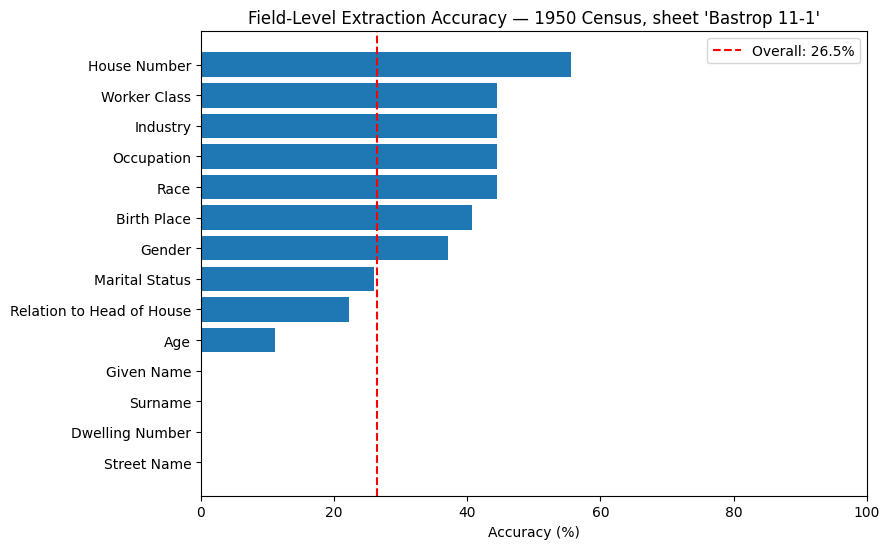

In [19]:
import matplotlib.pyplot as plt

scored_fields = {k: v for k, v in metrics["field_accuracy"].items() if v is not None}
sorted_fields = dict(sorted(scored_fields.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, max(4, len(sorted_fields) * 0.4)))
bars = ax.barh(list(sorted_fields.keys()), [v * 100 for v in sorted_fields.values()])
ax.set_xlabel("Accuracy (%)")
ax.set_xlim(0, 100)
ax.set_title(f"Field-Level Extraction Accuracy \u2014 {metrics['census_year']} Census, sheet '{metrics['sheet']}'")
ax.axvline(x=metrics["overall_field_accuracy"] * 100, color="red", linestyle="--",
           label=f"Overall: {metrics['overall_field_accuracy']:.1%}")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Inspect mismatches

Most useful step for deciding what to fix next: real extraction errors vs. known ground-truth limitations (like the 1950 W0/WO sub-code, or typos in certain sheets — see CLAUDE.md).

In [20]:
PRIORITY = PRIORITY_FIELDS_1950
mismatches=[]
for r in results:
 for field,d in r['fields'].items():
  if field not in PRIORITY or d['match']: continue
  mismatches.append({'line':r['line_number'],'field':field,'extracted':d['extracted'],'ground_truth':d['ground_truth']})
mismatch_df=pd.DataFrame(mismatches); print(f'Priority mismatches: {len(mismatch_df)}'); display(mismatch_df.head(30))


Priority mismatches: 147


,line,field,extracted,ground_truth
0,1,Surname,Judd,Whitehead
1,1,Given Name,Willie,Alec G
2,2,Surname,Judd,Whitehead
3,2,Given Name,Mary,Ida G
4,3,Surname,Judd,Whitehead
5,3,Given Name,Charles,C T
6,3,Age,25,19
7,4,Surname,Judd,Whitehead
8,4,Given Name,George,Charles L
9,4,Age,22,28


## 10. Save results

In [ ]:
save_path = RESULTS_DIR / f'page_{PHYSICAL_PAGE}_{IMAGE_FILENAME.replace(".jpg","")}.json'
payload = {'model': SELECTED_MODEL, 'metrics': metrics, 'results': results, 'records': extracted_records}
import json
with open(save_path, 'w') as f:
    json.dump(payload, f, indent=2, default=str)
print('Saved:', save_path)


## Notes on interpreting your accuracy numbers

- **Race field accuracy will not reach 100% on 1950 data** even with a perfect
  extractor. The ground truth's "W0"/"WO" sub-code is applied by the research
  team based on surname, not written anywhere on the physical census form —
  see CLAUDE.md section "VERIFIED Data Quality Findings" for the full
  investigation. Don't chase this to zero; flag it as a known, documented gap
  when you present results to Jaden.
- If you compare against a sheet other than `Bastrop 11-2A`, `Bastrop 11-3`,
  `Smithville 11-10`, `Elgin 11-20`, or `Elgin 11-21`, you may see stray
  ground-truth values (`'Whiite'`, `'White0'`, `'1'`, `'72'`, `'S'`, etc.) that
  are typos in the "clean" file itself, not extraction errors.
- To compare against Ancestry's own baseline OCR accuracy (to show the delta
  your pipeline achieves), use the paired Raw/Clean sheets in
  `Raw-Clean Comparison Document.xlsx` the same way — swap `gt_path` for that
  file and pick a `*_Raw` vs `*_Clean` sheet pair.

## Batch ED 11-1


In [ ]:
if RUN_BATCH:
 batch=[]; out=PROJECT_DIR/'results/colab_ide'; out.mkdir(parents=True,exist_ok=True)
 for page in BATCH_PAGES:
  img=IMAGE_DIR/f'sheet_{page:02d}.jpg'
  if not img.exists(): continue
  recs=extract_from_image(img,CENSUS_YEAR); m,res=compare(recs,GT_PATH,GROUND_TRUTH_SHEET,CENSUS_YEAR,page)
  batch.append({'page':page,'row':m['row_accuracy'],'field':m['overall_field_accuracy']}); print(page,m['row_accuracy'],m['overall_field_accuracy'])
 if batch: json.dump({'model':SELECTED_MODEL,'pages':batch},open(out/'batch_summary.json','w'),indent=2)
